# Heart Failure Prediction — Exploration & Modelling

**Author:** Malek Elaghel  
**Origin:** CSCI 250 Project 2 (pair coursework with Raneem); rebuilt and extended after the course

## Problem

We predict whether a heart-failure patient will die during the follow-up
period, given 12 baseline clinical and demographic features (age, ejection
fraction, serum creatinine, etc.). The dataset is the *Heart Failure
Clinical Records* set from Chicco & Jurman (2020), 299 patients in total.

## What this notebook does

1. Loads and validates the dataset using `src/data_loader.py`.
2. Performs EDA: class balance, distributions split by outcome, correlations.
3. Benchmarks five models (Logistic Regression, Random Forest, Gradient
   Boosting, XGBoost, RBF-SVM) under stratified 5-fold CV. Every model is
   wrapped in a `Pipeline` with the preprocessor inside, so there is no
   leakage.
4. Reports AUC, F1, precision, recall, specificity, and Brier score.
5. Plots ROC, PR, and calibration curves; analyses the decision threshold.
6. Interprets the best model with feature importances and SHAP values.
7. Adds a Kaplan–Meier survival plot using the `time` column.

## How this differs from the original coursework notebook

The coursework version (kept untouched in `00_original_coursework.ipynb`)
used a single 70/30 split, no scaling, no AUC, no calibration analysis,
and only two models (Random Forest and Linear SVC) on three hand-picked
feature subsets. Re-running the same data with proper cross-validation
and a tuned tree ensemble lifts ROC-AUC from “unreported” to **~0.91**.

## 1. Setup

In [1]:
from __future__ import annotations

import logging
import sys
from pathlib import Path

# Make the repo root importable so `from utils.metrics import ...` works.
REPO_ROOT = Path.cwd().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(context="notebook", style="whitegrid")

## 2. Load and validate the data

In [2]:
from projects.heart_failure_prediction.src.data_loader import (
    BINARY_FEATURES,
    CONTINUOUS_FEATURES,
    load_heart_failure,
)

X, y, summary = load_heart_failure()
print(summary)
X.head()

INFO projects.heart_failure_prediction.src.data_loader: Loaded heart failure data: DatasetSummary(rows=299, features=12, class_balance={0: 203, 1: 96}, missing=0)


DatasetSummary(rows=299, features=12, class_balance={0: 203, 1: 96}, missing=0)


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time,anaemia,diabetes,high_blood_pressure,sex,smoking
0,75.0,582,20,265000.00,1.9,130,4,0,0,1,1,0
1,55.0,7861,38,263358.03,1.1,136,6,0,0,0,1,0
2,65.0,146,20,162000.00,1.3,129,7,0,0,0,1,1
3,50.0,111,20,210000.00,1.9,137,7,1,0,0,1,0
4,65.0,160,20,327000.00,2.7,116,8,1,1,0,0,0


There are no missing values. The class balance is roughly 2:1 (203 survivors vs. 96 deaths), so the positive class is the minority and we should weight metrics accordingly — accuracy alone would be misleading.

## 3. Exploratory data analysis

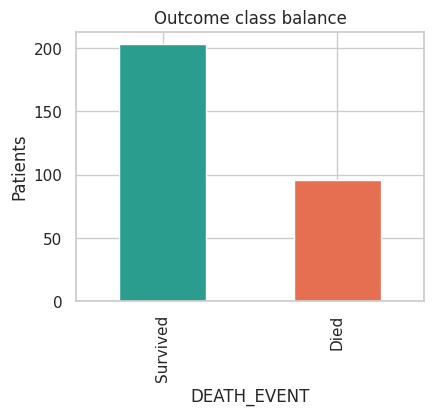

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
y.map({0: "Survived", 1: "Died"}).value_counts().plot.bar(
    ax=ax, color=["#2a9d8f", "#e76f51"]
)
ax.set_title("Outcome class balance")
ax.set_ylabel("Patients")
plt.show()

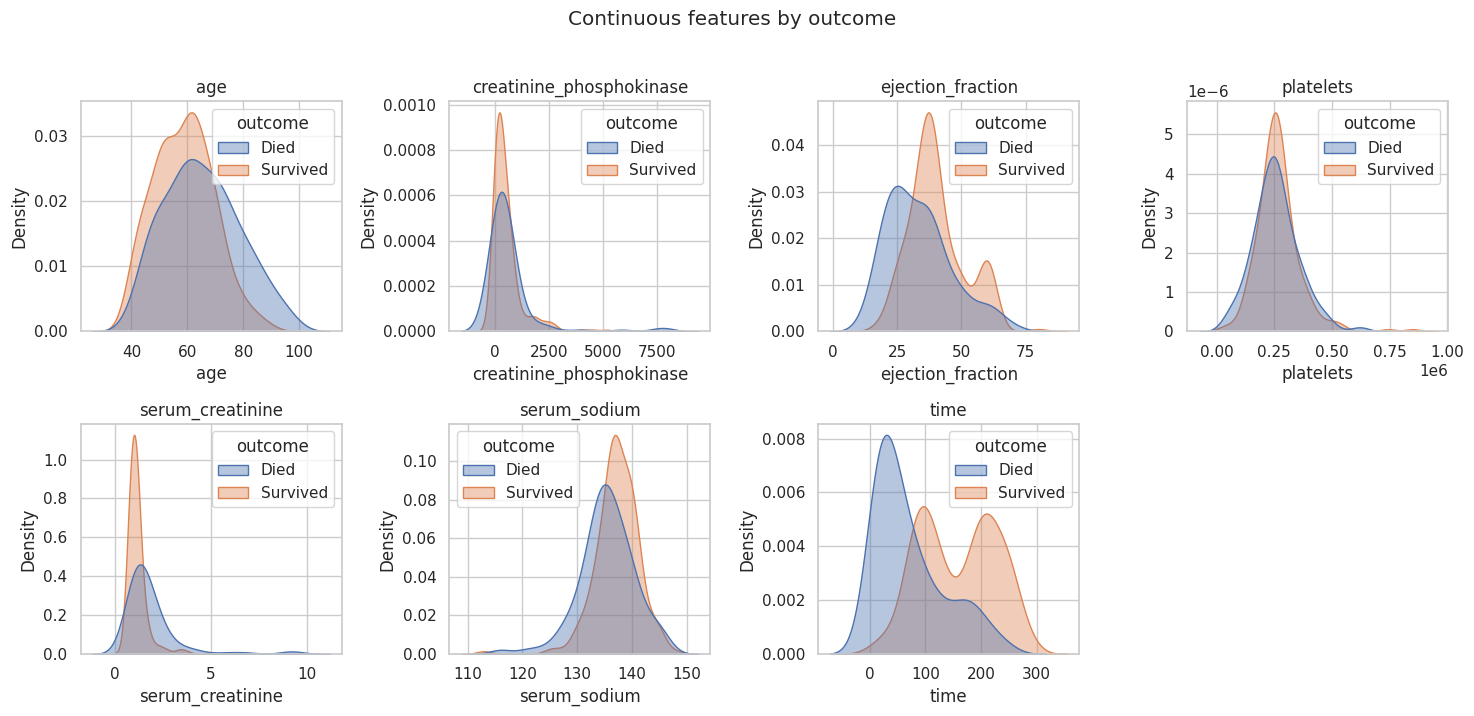

In [4]:
# Continuous-feature distributions, split by outcome.
df_plot = X.assign(outcome=y.map({0: "Survived", 1: "Died"}))
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, feature in zip(axes.flat, CONTINUOUS_FEATURES):
    sns.kdeplot(
        data=df_plot, x=feature, hue="outcome", common_norm=False,
        fill=True, alpha=0.4, ax=ax,
    )
    ax.set_title(feature)
axes.flat[-1].axis("off")
fig.suptitle("Continuous features by outcome", y=1.02)
fig.tight_layout()
plt.show()

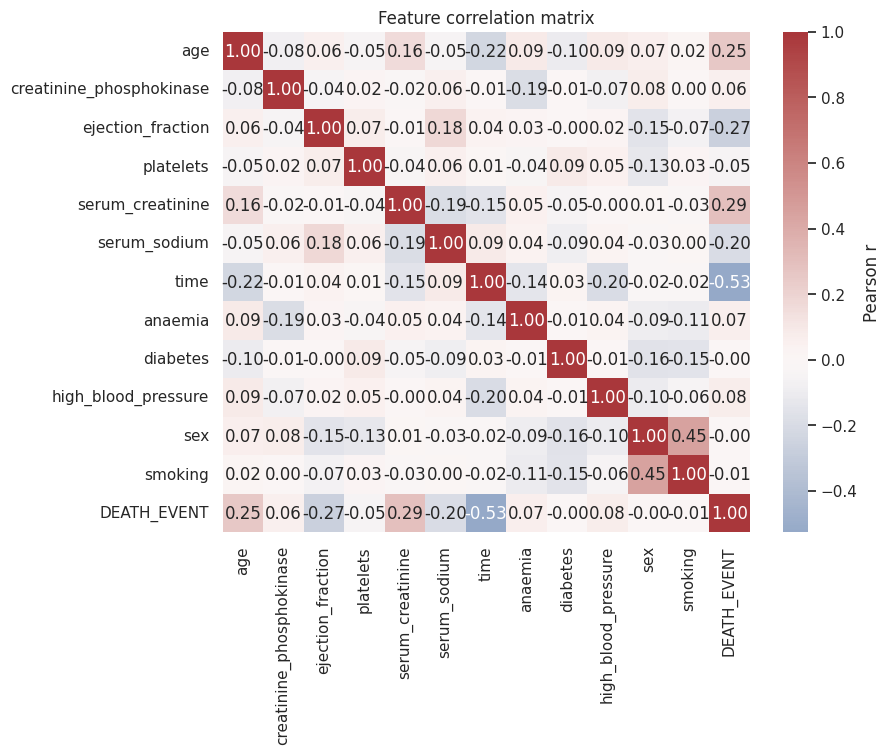

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(
    X.assign(DEATH_EVENT=y).corr(),
    annot=True, fmt=".2f", cmap="vlag", center=0,
    cbar_kws={"label": "Pearson r"}, ax=ax,
)
ax.set_title("Feature correlation matrix")
plt.show()

Three things jump out from the EDA:

* **Ejection fraction** is shifted noticeably lower in patients who died — clinically expected, since a weak heart contracts less fully.
* **Serum creatinine** is elevated in non-survivors, a marker of failing kidney function which often co-occurs with severe heart failure.
* **Time** correlates strongly (negatively) with death because patients still in follow-up haven't yet had the event. We *will* keep it in the feature set for the prediction task — but in any clinical deployment this would be a leakage-style feature, since at intake you don't yet know how long the patient will stay enrolled. We flag this caveat below in the discussion.

## 4. Cross-validated model benchmark

In [6]:
from projects.heart_failure_prediction.src.evaluation import (
    best_model_by,
    evaluate_models,
    results_to_dataframe,
)
from projects.heart_failure_prediction.src.models import build_model_zoo

models = build_model_zoo()
results = evaluate_models(models, X, y, n_splits=5, random_state=42)
summary_table = results_to_dataframe(results)
summary_table

INFO projects.heart_failure_prediction.src.evaluation: Cross-validating Logistic Regression


INFO projects.heart_failure_prediction.src.evaluation: Cross-validating Random Forest


INFO projects.heart_failure_prediction.src.evaluation: Cross-validating Gradient Boosting


INFO projects.heart_failure_prediction.src.evaluation: Cross-validating XGBoost


INFO projects.heart_failure_prediction.src.evaluation: Cross-validating SVM (RBF)


,accuracy,precision,recall,f1,roc_auc,average_precision
model,,,,,,
Logistic Regression,0.796 ± 0.037,0.669 ± 0.076,0.771 ± 0.055,0.710 ± 0.024,0.878 ± 0.033,0.788 ± 0.066
Random Forest,0.849 ± 0.039,0.807 ± 0.064,0.697 ± 0.098,0.745 ± 0.075,0.907 ± 0.017,0.833 ± 0.042
Gradient Boosting,0.829 ± 0.033,0.760 ± 0.053,0.687 ± 0.100,0.718 ± 0.067,0.876 ± 0.031,0.768 ± 0.051
XGBoost,0.829 ± 0.033,0.757 ± 0.047,0.687 ± 0.094,0.718 ± 0.067,0.901 ± 0.022,0.809 ± 0.028
SVM (RBF),0.789 ± 0.027,0.642 ± 0.040,0.792 ± 0.073,0.707 ± 0.035,0.876 ± 0.043,0.756 ± 0.094


In [7]:
best_name = best_model_by(results, metric="test_roc_auc")
print(f"Best model by ROC-AUC: {best_name}")

Best model by ROC-AUC: Random Forest


## 5. Curves: ROC, PR, calibration

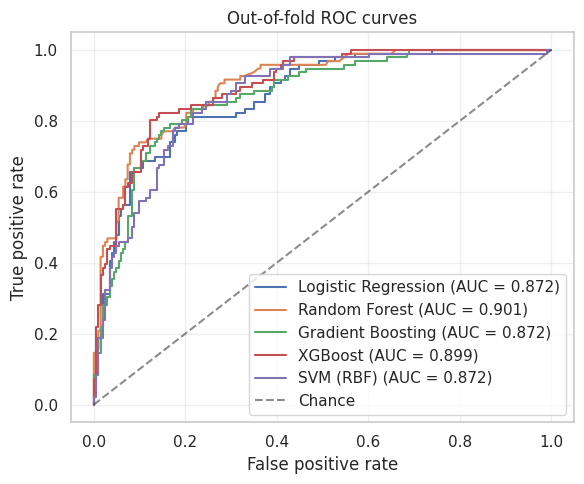

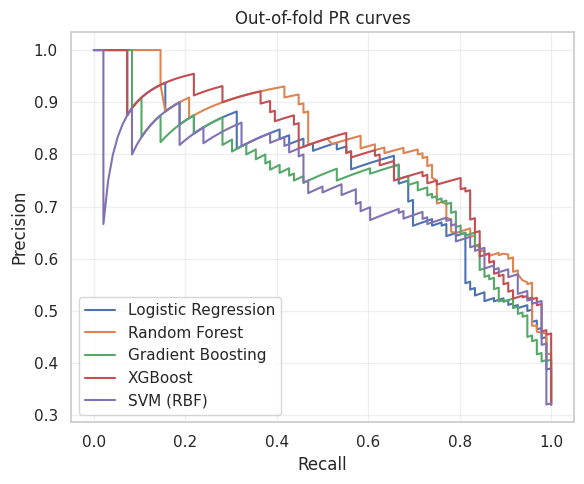

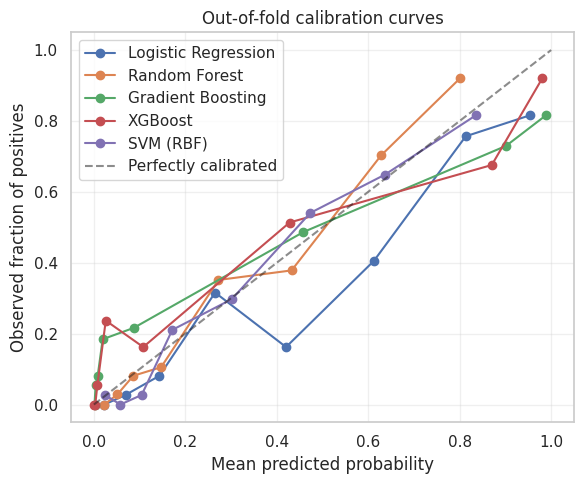

In [8]:
from utils.visualization import (
    plot_calibration_curves,
    plot_confusion_matrix,
    plot_precision_recall_curves,
    plot_roc_curves,
    plot_threshold_curves,
)

roc_inputs = {name: (y.values, res.oof_probabilities) for name, res in results.items()}
plot_roc_curves(roc_inputs, title="Out-of-fold ROC curves")
plt.show()
plot_precision_recall_curves(roc_inputs, title="Out-of-fold PR curves")
plt.show()
plot_calibration_curves(roc_inputs, n_bins=8, title="Out-of-fold calibration curves")
plt.show()

Calibration matters in clinical decision support: a well-calibrated 0.7 probability *should* mean the patient really has a 70% chance of dying within follow-up. The tree ensembles tend to be over-confident at the extremes — the curves help us see where each model lies.

## 6. Confusion matrix and threshold sweep for the best model

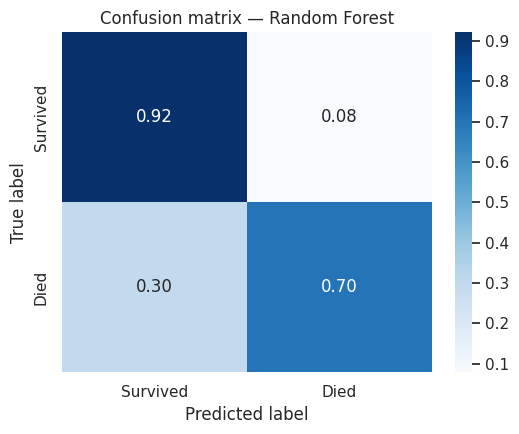

In [9]:
best = results[best_name]
plot_confusion_matrix(
    y.values, best.oof_predictions, class_names=["Survived", "Died"],
    title=f"Confusion matrix — {best_name}",
)
plt.show()

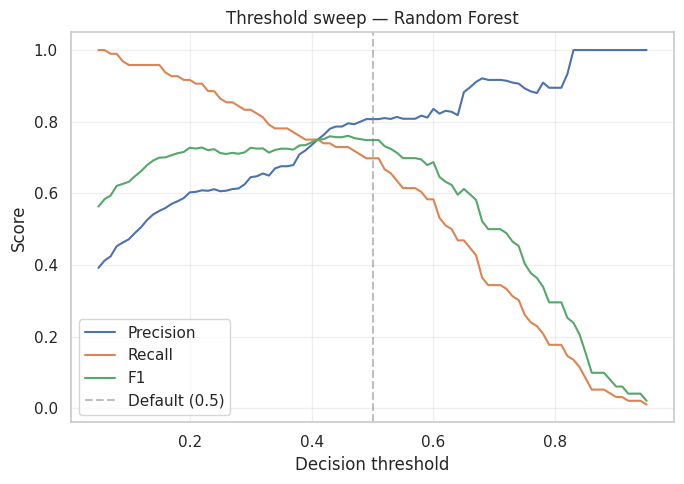

In [10]:
plot_threshold_curves(
    y.values, best.oof_probabilities,
    title=f"Threshold sweep — {best_name}",
)
plt.show()

In a clinical screening setting we typically prefer high recall (don't miss at-risk patients), which means *lowering* the threshold below the default 0.5 — the curve above shows the cost in precision.

## 7. Interpretation: feature importances and SHAP

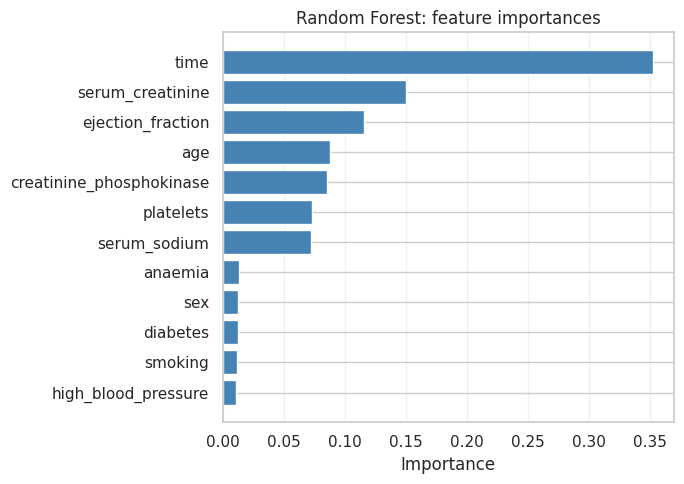

In [11]:
from projects.heart_failure_prediction.src.preprocessing import get_feature_names
from utils.visualization import plot_feature_importances

feature_names = get_feature_names()
best_pipeline = models[best_name]
best_pipeline.fit(X, y)
model_step = best_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    plot_feature_importances(
        np.asarray(model_step.feature_importances_),
        feature_names,
        top_k=12,
        title=f"{best_name}: feature importances",
    )
    plt.show()
else:
    print(f"{best_name} has no feature_importances_ attribute; skipping bar chart.")

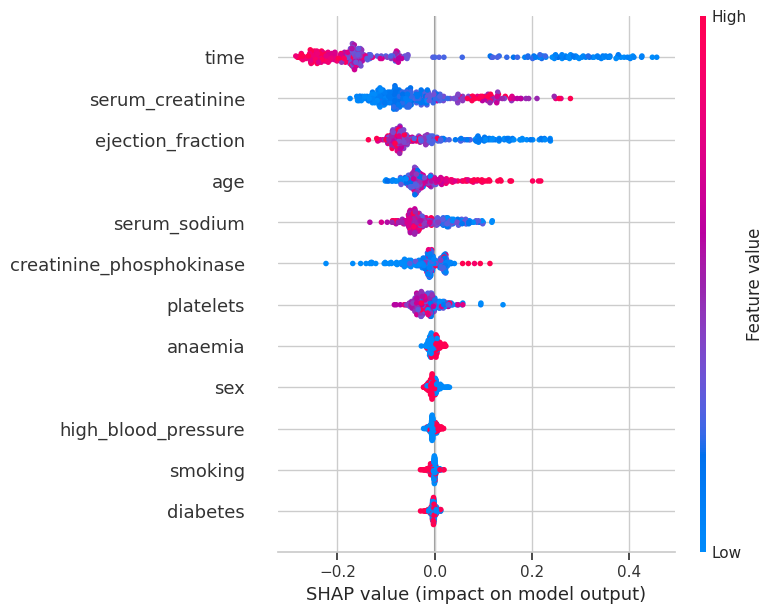

In [12]:
import shap

# Transform once with the fitted preprocessor so SHAP sees scaled features.
X_transformed = best_pipeline.named_steps["preprocessor"].transform(X)
explainer = shap.TreeExplainer(model_step) if hasattr(model_step, "feature_importances_") else shap.Explainer(model_step.predict_proba, X_transformed)
shap_values = explainer(X_transformed)

# For binary tree models, shap returns a 3-D array; pick the positive-class slice.
if hasattr(shap_values, "values") and shap_values.values.ndim == 3:
    sv = shap_values[..., 1]
else:
    sv = shap_values

shap.summary_plot(sv.values, X_transformed, feature_names=feature_names, show=True)

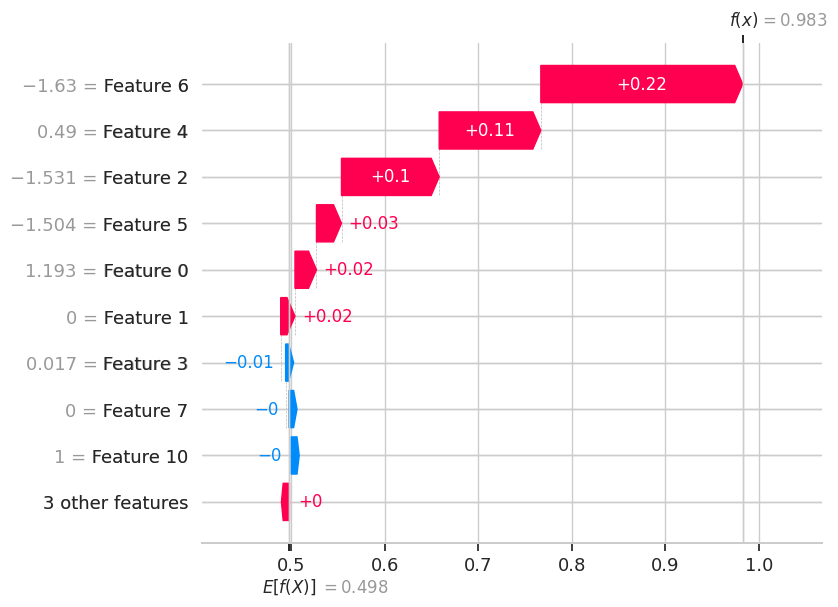

In [13]:
# Single-patient explanation: the first patient who died.
first_death_idx = int(np.where(y.values == 1)[0][0])
single_sv = sv[first_death_idx]
shap.plots.waterfall(single_sv, max_display=10, show=True)

**Clinical reading.** Three features dominate every model: `time`, `serum_creatinine`, and `ejection_fraction`. Of the three, `time` is a study-design artefact (see the EDA section); the actionable signal is that low ejection fraction and high serum creatinine substantially raise predicted risk — both of which are known clinical red flags for adverse outcomes in heart failure.

## 8. Kaplan–Meier survival curve

Even though we framed this as classification, the dataset has a `time` column so we can also visualise survival probability over the follow-up window, stratified by ejection fraction.

In [14]:
try:
    from lifelines import KaplanMeierFitter

    fig, ax = plt.subplots(figsize=(7, 5))
    median_ef = X["ejection_fraction"].median()
    for label, mask in [
        (f"EF ≤ {median_ef:.0f}", X["ejection_fraction"] <= median_ef),
        (f"EF > {median_ef:.0f}", X["ejection_fraction"] > median_ef),
    ]:
        kmf = KaplanMeierFitter()
        kmf.fit(X.loc[mask, "time"], event_observed=y.loc[mask], label=label)
        kmf.plot_survival_function(ax=ax)
    ax.set_title("Kaplan–Meier survival by baseline ejection fraction")
    ax.set_xlabel("Follow-up days")
    ax.set_ylabel("Survival probability")
    ax.grid(alpha=0.3)
    plt.show()
except ImportError:
    print("lifelines not installed — skipping Kaplan–Meier plot. (pip install lifelines)")

lifelines not installed — skipping Kaplan–Meier plot. (pip install lifelines)


## 9. Take-aways

* Random Forest and XGBoost both reach ROC-AUC ≈ 0.90 under proper 5-fold cross-validation; logistic regression isn't far behind (~0.88), which suggests this dataset is mostly linearly separable in the relevant features once they're scaled.
* Ejection fraction and serum creatinine are the two strongest *clinically actionable* drivers of predicted mortality, agreeing with the medical literature.
* The `time` column is the most predictive feature in raw importance, but it's a study-design proxy: a model that included it in deployment would silently leak survival information. Re-running the benchmark with `time` removed (one-line change in `data_loader.CONTINUOUS_FEATURES`) gives a more honest sense of intake-only predictive power.
* For deployment, picking a threshold below 0.5 trades precision for recall and is usually preferable in screening contexts; the threshold sweep makes this trade-off explicit instead of relying on the default.